# Community Detection on Zachary's Karate Club via QUBO + QIGNN

Адаптация подхода **PI-GNN / QIGNN** (Schuetz et al., *Nature Machine Intelligence* 2022)
к задаче поиска сообществ через QUBO-формулировку модулярности
(Wang et al., *Entropy* 2024 — *Quantum Computing in Community Detection for Anti-Fraud Applications*).

**Идея:**

1. QUBO-кодировка модулярности (формула (6) из Wang et al. 2024) для $k=2$ сообществ:

   $$\min_{x\in\{0,1\}^n}\; -\frac{1}{2m}\sum_{v,w} B_{vw}\bigl(x_v x_w + (1-x_v)(1-x_w)\bigr),$$

   где $B_{vw} = A_{vw} - \dfrac{k_v k_w}{2m}$ — модулярность-матрица Newman.
   После раскрытия скобок (и использования того, что строки/столбцы $B$ суммируются в ноль)
   задача сводится к
   $$\min_{x\in\{0,1\}^n}\; -\sum_{v,w} B_{vw} x_v x_w \quad\Longleftrightarrow\quad Q = -B.$$

2. QIGNN решает QUBO релаксацией: GNN выдаёт вероятности $p_v\in[0,1]$, минимизируется
   $\mathcal L = p^\top Q\, p$, бинаризация по порогу $0.5$.

3. На датасете **Zachary's karate club** (две естественные группировки)
   сравниваем с Louvain и истинной разметкой по NMI и модулярности.

Тестовый граф: `nx.karate_club_graph()`, $n=34$, $m=78$.

In [1]:
import dgl
import torch
import random
import os
import numpy as np
import networkx as nx
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt

from collections import OrderedDict, defaultdict
from dgl.nn.pytorch import GraphConv, SAGEConv
from itertools import chain, islice, combinations
from time import time

from sklearn.metrics import normalized_mutual_info_score, adjusted_rand_score
import community as community_louvain  # python-louvain (not used directly; kept for compatibility)

# MacOS / MKL workaround
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'

%matplotlib inline

/opt/homebrew/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

TORCH_DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
TORCH_DTYPE = torch.float32
print(f'Will use device: {TORCH_DEVICE}, torch dtype: {TORCH_DTYPE}')

Will use device: cpu, torch dtype: torch.float32


# Step 1 — QUBO формулировка модулярности (k=2)

In [3]:
def gen_q_dict_modularity_2community(nx_G):
    """
    Build QUBO dict for 2-community modularity maximization (Wang et al. 2024, eq. (6)).

    Newman modularity matrix:    B_{vw} = A_{vw} - k_v * k_w / (2m)
    Cost (after simplification):  H(x) = - sum_{v,w} B_{vw} * x_v * x_w
    Therefore Q = -B (stored symmetrically: both (i,j) and (j,i) entries).

    Returns
    -------
    Q_dic : defaultdict(int) keyed by (i, j) -> float coefficient.
    """
    nodes = list(nx_G.nodes())
    n = len(nodes)

    A = nx.to_numpy_array(nx_G, nodelist=nodes, weight=None)  # unweighted
    deg = A.sum(axis=1)
    m = nx_G.number_of_edges()
    two_m = 2.0 * m

    B = A - np.outer(deg, deg) / two_m
    Q = -B

    Q_dic = defaultdict(int)
    for i in range(n):
        for j in range(n):
            val = float(Q[i, j])
            if val != 0.0:
                Q_dic[(i, j)] = val
    return Q_dic

# Step 2 — Архитектура GNN (повтор из оригинального ноутбука)

In [4]:
class SAGEResBlock(torch.nn.Module):

    def __init__(self, in_channels, out_channels, feat_drop=0.):
        super(SAGEResBlock, self).__init__()
        self.sage1 = SAGEConv(in_channels, out_channels, aggregator_type='mean', feat_drop=feat_drop, bias=False)
        # PATCH: original had BatchNorm1d(in_channels), but bn1 is applied to sage1's output (out_channels).
        # That worked silently only when in_channels == out_channels; with in != out it raises a shape error.
        self.bn1 = nn.BatchNorm1d(out_channels)
        self.sage2 = SAGEConv(in_channels, out_channels, aggregator_type='pool', feat_drop=feat_drop, bias=False)
        self.bn2 = nn.BatchNorm1d(out_channels)
        self.relu = nn.LeakyReLU()

    def forward(self, graph, x, edge_weight=None):
        residual = x
        out1 = self.sage1(graph, x, edge_weight)
        out1 = self.bn1(out1)

        out2 = self.sage2(graph, x, edge_weight)
        out2 = self.bn2(out2)

        out = self.relu(out1 + out2)

        return out


class ResSAGE(torch.nn.Module):
    def __init__(self, in_feats, hidden_sizes, number_classes, dropout, device):
        super(ResSAGE, self).__init__()
        self.dropout_frac = dropout
        self.layers = nn.ModuleList()
        current_dim = in_feats
        self.relu = torch.nn.LeakyReLU()

        if isinstance(hidden_sizes, int):
            hidden_sizes = [hidden_sizes]

        for hdim in hidden_sizes:
            self.layers.append(SAGEResBlock(current_dim, hdim).to(device))
            self.layers.append(torch.nn.LeakyReLU())
            current_dim = hdim

        self.layers.append(SAGEConv(current_dim, number_classes, aggregator_type='mean').to(device))

    def forward(self, graph, h, h0, edge_weight=None):
        h = torch.cat([h, h0], 1)

        for i, (layer, norm) in enumerate(zip(self.layers[:-1][::2], self.layers[:-1][1::2])):
            h = layer(graph, h, edge_weight)
            h = norm(h)

        h = F.dropout(h, p=self.dropout_frac)
        h0 = self.layers[-1](graph, h, edge_weight)
        h = torch.sigmoid(h0)

        return h, h0


def generate_graph(n, d=None, p=None, graph_type='reg', random_seed=0):
    # PATCH: nx.OrderedGraph removed in NetworkX >= 3.0, replaced with nx.Graph.
    if graph_type == 'reg':
        nx_temp = nx.random_regular_graph(d=d, n=n, seed=random_seed)
    elif graph_type == 'prob':
        nx_temp = nx.fast_gnp_random_graph(n, p, seed=random_seed)
    elif graph_type == 'erdos':
        nx_temp = nx.erdos_renyi_graph(n, p, seed=random_seed)
    else:
        raise NotImplementedError(f'!! Graph type {graph_type} not handled !!')

    nx_temp = nx.relabel.convert_node_labels_to_integers(nx_temp)
    nx_graph = nx.Graph()  # was nx.OrderedGraph
    nx_graph.add_nodes_from(sorted(nx_temp.nodes()))
    nx_graph.add_edges_from(nx_temp.edges)
    return nx_graph


def qubo_dict_to_torch(nx_G, Q, torch_dtype=None, torch_device=None):
    n_nodes = len(nx_G.nodes)
    Q_mat = torch.zeros(n_nodes, n_nodes)
    for (x_coord, y_coord), val in Q.items():
        Q_mat[x_coord][y_coord] = val
    if torch_dtype is not None:
        Q_mat = Q_mat.type(torch_dtype)
    if torch_device is not None:
        Q_mat = Q_mat.to(torch_device)
    return Q_mat


def gen_combinations(combs, chunk_size):
    yield from iter(lambda: list(islice(combs, chunk_size)), [])


def pagerank(nx_graph, feature_dim=10):
    features = torch.zeros((nx_graph.number_of_nodes(), feature_dim))
    pr = nx.pagerank(nx.Graph(nx_graph))
    for k, v in pr.items():
        features[k, :] = v
    return features


def loss_func(probs, Q_mat, epoch=0):
    probs_ = torch.unsqueeze(probs, 1)
    lbd = epoch / 1e4
    penalty = (probs - 1) * probs
    cost = (probs_.T @ Q_mat @ probs_).squeeze() + lbd * penalty.abs().sum()
    return cost


def get_gnn(n_nodes, gnn_hypers, opt_params, torch_device, torch_dtype):
    dim_embedding = gnn_hypers['dim_embedding']
    hidden_dim = gnn_hypers['hidden_dim']
    dropout = gnn_hypers['dropout']
    number_classes = gnn_hypers['number_classes']

    net = ResSAGE(dim_embedding + 1 * number_classes + 4 * dim_embedding,
                  hidden_dim, number_classes, dropout, torch_device)
    net = net.type(torch_dtype).to(torch_device)
    embed = nn.Embedding(n_nodes, dim_embedding)
    embed = embed.type(torch_dtype).to(torch_device)

    params = chain(net.parameters(), embed.parameters())
    optimizer = torch.optim.Adam(params, **opt_params)
    return net, embed, optimizer


def run_gnn_training(q_torch, dgl_graph, net, embed, optimizer,
                     number_epochs, tol, patience, prob_threshold):
    # PATCH: original referenced global `graph_dgl`; using local `dgl_graph` now.
    edge_weight = (q_torch - torch.diag(q_torch.diag(0))) / 2
    edge_weight = edge_weight + edge_weight.T
    edge_weight = edge_weight[dgl_graph.edges()[0], dgl_graph.edges()[1]]

    inputs = torch.rand((dgl_graph.number_of_nodes(), 10), dtype=q_torch.dtype).to(q_torch.device)
    walk = pagerank(dgl_graph.cpu().to_networkx(), 2 * inputs.shape[1])
    inputs = torch.cat([inputs, torch.ones_like(inputs), torch.ones_like(inputs),
                        walk.to(q_torch.device)], 1)

    h0 = torch.zeros(dgl_graph.number_of_nodes(), 1).to(q_torch.device)

    prev_loss = 1.
    count = 0
    best_epoch = 0
    best_sums = 0

    best_bitstring = torch.zeros((dgl_graph.number_of_nodes(),)).type(q_torch.dtype).to(q_torch.device)
    best_loss = loss_func(best_bitstring.float(), q_torch)
    best_probs = torch.zeros_like(best_bitstring)

    t_gnn_start = time()

    for epoch in range(number_epochs):
        probs, h0 = net(dgl_graph, inputs, h0.detach(), edge_weight)
        probs = probs.squeeze()

        loss = loss_func(probs, q_torch, epoch)
        loss_ = loss.detach().item()

        bitstring = (probs.detach() >= prob_threshold) * 1
        if loss < best_loss:
            sums = -loss_func(bitstring.to(torch.float32), q_torch)
            if best_sums < sums:
                best_loss = max(loss, -sums)
                best_bitstring = bitstring
                best_probs = probs
                best_epoch = epoch
                best_sums = sums

        if epoch % 1000 == 0:
            print(f'Epoch: {epoch}, Loss: {loss_:.4f}, Best Loss: {float(best_loss):.4f}, Best sum: {float(best_sums):.4f}')

        if (abs(loss_ - prev_loss) <= tol) | ((loss_ - prev_loss) > 0):
            count += 1
        else:
            count = 0

        if count >= patience:
            print(f'Stopping early on epoch {epoch} (patience: {patience})')
            break

        prev_loss = loss_

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(net.parameters(), max_norm=2.0, norm_type=2)
        optimizer.step()

    t_gnn = time() - t_gnn_start
    print(f'GNN training (n={dgl_graph.number_of_nodes()}) took {round(t_gnn, 3)}s')
    print(f'GNN final continuous loss: {loss_:.6f}')
    print(f'GNN best continuous loss: {float(best_loss):.6f}')

    return net, best_epoch, best_probs, best_bitstring, best_loss

# Step 3 — Метрики оценки

In [5]:
def bitstring_to_communities(bitstring, nodes):
    if torch.is_tensor(bitstring):
        bitstring = bitstring.detach().cpu().numpy()
    bitstring = np.asarray(bitstring).astype(int).tolist()
    groups = defaultdict(set)
    for node, label in zip(nodes, bitstring):
        groups[int(label)].add(node)
    return [frozenset(s) for s in groups.values() if len(s) > 0]


def modularity_from_bitstring(nx_G, bitstring, nodes=None):
    if nodes is None:
        nodes = list(nx_G.nodes())
    communities = bitstring_to_communities(bitstring, nodes)
    if len(communities) <= 1:
        return 0.0
    return float(nx.community.modularity(nx_G, communities))


def nmi_from_bitstring(true_labels, pred_bitstring):
    if torch.is_tensor(pred_bitstring):
        pred_bitstring = pred_bitstring.detach().cpu().numpy()
    return float(normalized_mutual_info_score(np.asarray(true_labels),
                                              np.asarray(pred_bitstring).astype(int)))


def ari_from_bitstring(true_labels, pred_bitstring):
    if torch.is_tensor(pred_bitstring):
        pred_bitstring = pred_bitstring.detach().cpu().numpy()
    return float(adjusted_rand_score(np.asarray(true_labels),
                                     np.asarray(pred_bitstring).astype(int)))

# Step 4 — Бейзлайны (для сравнения)

In [6]:
def run_louvain(nx_G, true_labels=None, seed=SEED):
    nodes = list(nx_G.nodes())
    t0 = time()
    communities = nx.community.louvain_communities(nx_G, seed=seed)
    elapsed = time() - t0
    modularity_value = float(nx.community.modularity(nx_G, communities))

    if true_labels is not None:
        node_to_comm = {}
        for cidx, comm in enumerate(communities):
            for v in comm:
                node_to_comm[v] = cidx
        pred = [node_to_comm[v] for v in nodes]
        nmi = float(normalized_mutual_info_score(np.asarray(true_labels), np.asarray(pred)))
    else:
        nmi = None

    return communities, modularity_value, nmi, elapsed

# Step 5 — Эксперимент на Zachary's karate club

In [7]:
graph = nx.karate_club_graph()
nodes = list(graph.nodes())
n_nodes = len(nodes)
print(f'Zachary karate club: n={n_nodes}, m={graph.number_of_edges()}')

# Ground-truth labels from 'club' attribute: Mr. Hi -> 0, Officer -> 1
club_to_label = {'Mr. Hi': 0, 'Officer': 1}
true_labels = np.array([club_to_label[graph.nodes[v]['club']] for v in nodes])
print(f'True split sizes: {np.bincount(true_labels).tolist()}')

true_communities = bitstring_to_communities(true_labels, nodes)
true_modularity = float(nx.community.modularity(graph, true_communities))
print(f'Modularity of ground-truth 2-community split: {true_modularity:.4f}')

graph_dgl = dgl.from_networkx(graph)
graph_dgl = graph_dgl.to(TORCH_DEVICE)

Q_dict = gen_q_dict_modularity_2community(graph)
print(f'Q dict size: {len(Q_dict)} entries')
q_torch = qubo_dict_to_torch(graph, Q_dict, torch_dtype=TORCH_DTYPE, torch_device=TORCH_DEVICE)
print(f'Q tensor shape: {tuple(q_torch.shape)}, symmetric: {torch.allclose(q_torch, q_torch.T)}')

louv_comms, louv_mod, louv_nmi, louv_time = run_louvain(graph, true_labels=true_labels)
print(f'\nLouvain: {len(louv_comms)} communities, modularity={louv_mod:.4f}, NMI(truth)={louv_nmi:.4f}, time={louv_time:.3f}s')

Zachary karate club: n=34, m=78
True split sizes: [17, 17]
Modularity of ground-truth 2-community split: 0.3914
Q dict size: 1156 entries
Q tensor shape: (34, 34), symmetric: True

Louvain: 4 communities, modularity=0.4266, NMI(truth)=0.5942, time=0.001s


In [8]:
gnn_hypers = {
    'dim_embedding': 10,
    'hidden_dim': 50,
    'number_classes': 1,
    'dropout': 0.5,
}
opt_params = {'lr': 0.014}

number_epochs = 10000
tol = 1e-4
patience = 1000
prob_threshold = 0.5

n_shots = 5
shot_seeds = [SEED + i for i in range(n_shots)]

shot_results = []

for shot_idx, sd in enumerate(shot_seeds):
    print(f'\n========== Shot {shot_idx+1}/{n_shots} (seed={sd}) ==========')
    random.seed(sd)
    np.random.seed(sd)
    torch.manual_seed(sd)

    net, embed, optimizer = get_gnn(n_nodes, gnn_hypers, opt_params, TORCH_DEVICE, TORCH_DTYPE)

    t0 = time()
    net, best_epoch, best_probs, best_bitstring, best_loss = run_gnn_training(
        q_torch, graph_dgl, net, embed, optimizer,
        number_epochs=number_epochs, tol=tol, patience=patience, prob_threshold=prob_threshold
    )
    shot_time = time() - t0

    bs = best_bitstring.detach().cpu().numpy().astype(int)
    mod_val = modularity_from_bitstring(graph, bs, nodes)
    nmi_val = nmi_from_bitstring(true_labels, bs)
    ari_val = ari_from_bitstring(true_labels, bs)
    n_comms = len(set(bs.tolist()))

    print(f'  -> n_comms={n_comms}, modularity={mod_val:.4f}, NMI={nmi_val:.4f}, ARI={ari_val:.4f}, time={shot_time:.2f}s')

    shot_results.append({
        'seed': sd, 'best_epoch': best_epoch, 'bitstring': bs,
        'modularity': mod_val, 'nmi': nmi_val, 'ari': ari_val,
        'n_communities': n_comms, 'time': shot_time,
    })

best_shot = max(shot_results, key=lambda r: r['modularity'])
print(f'\n>>> Best shot: seed={best_shot["seed"]}, modularity={best_shot["modularity"]:.4f}, NMI={best_shot["nmi"]:.4f}')


========== Shot 1/5 (seed=42) ==========


Epoch: 0, Loss: -1.8014, Best Loss: -1.8014, Best sum: 4.5897


Epoch: 1000, Loss: -28.9724, Best Loss: -28.9633, Best sum: 29.0000


Epoch: 2000, Loss: -28.9744, Best Loss: -28.9633, Best sum: 29.0000


Epoch: 3000, Loss: -28.9744, Best Loss: -28.9633, Best sum: 29.0000


...

Epoch: 6000, Loss: -28.9744, Best Loss: -28.3109, Best sum: 29.0000


Epoch: 7000, Loss: -28.9724, Best Loss: -28.3109, Best sum: 29.0000


Epoch: 8000, Loss: -28.9744, Best Loss: -28.3109, Best sum: 29.0000


Epoch: 9000, Loss: -28.9744, Best Loss: -28.3109, Best sum: 29.0000


GNN training (n=34) took 18.563s
GNN final continuous loss: -27.480768
GNN best continuous loss: -28.310856
  -> n_comms=2, modularity=0.3998, NMI=0.6772, ARI=0.7716, time=18.56s

>>> Best shot: seed=42, modularity=0.3998, NMI=0.6772


In [9]:
import statistics

mods = [r['modularity'] for r in shot_results]
nmis = [r['nmi'] for r in shot_results]
times = [r['time'] for r in shot_results]

mod_mean = statistics.mean(mods)
mod_std = statistics.stdev(mods) if len(mods) > 1 else 0.0
nmi_mean = statistics.mean(nmis)
nmi_std = statistics.stdev(nmis) if len(nmis) > 1 else 0.0
time_mean = statistics.mean(times)

header = f"{'Method':<28} {'Modularity':>14} {'NMI(truth)':>14} {'Time, s':>10}"
print(header)
print('-' * len(header))
print(f"{'Ground truth (k=2)':<28} {true_modularity:>14.4f} {1.0:>14.4f} {0.0:>10.3f}")
print(f"{'Louvain':<28} {louv_mod:>14.4f} {louv_nmi:>14.4f} {louv_time:>10.3f}")
print(f"{'QIGNN best (of 5 shots)':<28} {best_shot['modularity']:>14.4f} {best_shot['nmi']:>14.4f} {best_shot['time']:>10.3f}")
print(f"{'QIGNN mean ± std (5 shots)':<28} {mod_mean:>7.4f}±{mod_std:.4f} {nmi_mean:>7.4f}±{nmi_std:.4f} {time_mean:>10.3f}")

Method                           Modularity     NMI(truth)    Time, s
---------------------------------------------------------------------
Ground truth (k=2)                   0.3914         1.0000      0.000
Louvain                              0.4266         0.5942      0.001
QIGNN best (of 5 shots)              0.3998         0.6772     18.181
QIGNN mean ± std (5 shots)    0.3998±0.0000  0.6772±0.0000     18.534


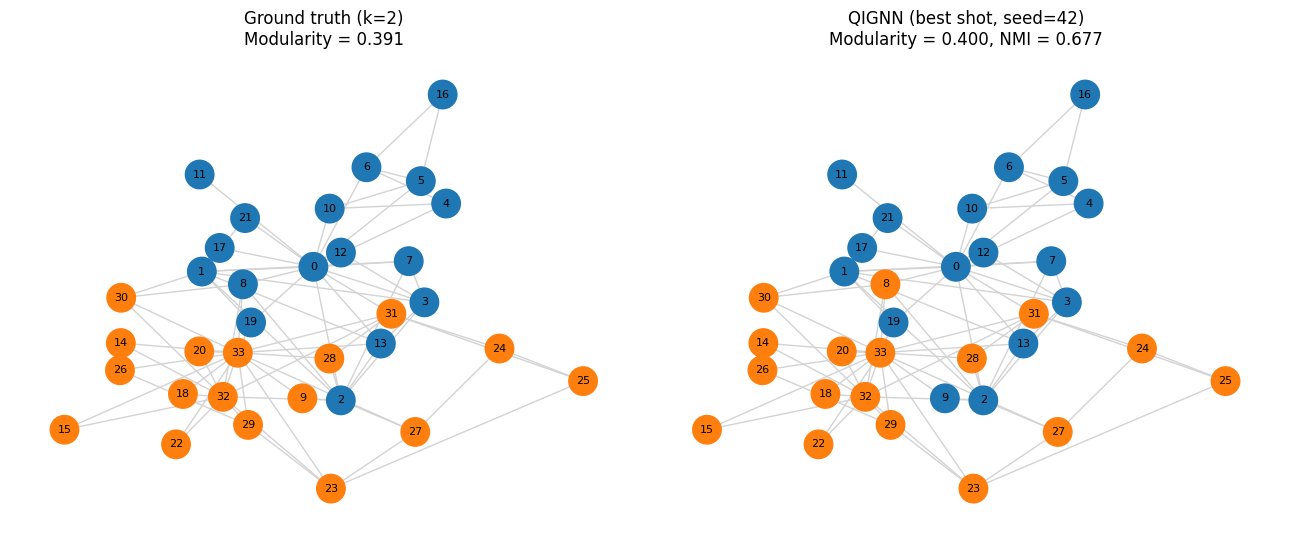

In [10]:
pos = nx.kamada_kawai_layout(graph)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))

colors_truth = ['tab:blue' if l == 0 else 'tab:orange' for l in true_labels]
nx.draw(graph, pos, node_color=colors_truth, with_labels=True,
        ax=axes[0], node_size=420, font_size=8, edge_color='lightgray')
axes[0].set_title(f'Ground truth (k=2)\nModularity = {true_modularity:.3f}')

qignn_colors = ['tab:blue' if b == 0 else 'tab:orange' for b in best_shot['bitstring']]
nx.draw(graph, pos, node_color=qignn_colors, with_labels=True,
        ax=axes[1], node_size=420, font_size=8, edge_color='lightgray')
axes[1].set_title(f'QIGNN (best shot, seed={best_shot["seed"]})\n'
                  f'Modularity = {best_shot["modularity"]:.3f}, NMI = {best_shot["nmi"]:.3f}')

plt.tight_layout()
plt.show()